<a href="https://colab.research.google.com/github/alyona-vishnoi/learning-RL/blob/main/FrozenLake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium

In [2]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=False)

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

state, info = env.reset()
print("Starting state:", state)

Number of states: 16
Number of actions: 4
Starting state: 0


In [3]:
Q = np.zeros([env.observation_space.n, env.action_space.n])
print(Q.shape)  # (16, 4)

(16, 4)


In [4]:
print(Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
state, info = env.reset()
action = env.action_space.sample()  # random action

# Take one step:
next_state, reward, terminated, truncated, info = env.step(action)
# u were in u, you took action, and the environment returned what happened next
print("state:", state)
print("action:", action)
# For FrozenLake the logic is dead simple:
# if the tile you land on is the goal, reward = 1.
print("reward:", reward)
# next state is where u ended up after action u took
print("next_state:", next_state)
print("terminated:", terminated) # related to mdp
print("truncated:", truncated) # related to time or smth
print("info:", info)
"""
That number only matters if is_slippery=True.
On a slippery tile, when you choose an action like "move right,"
the ice causes you to actually move in one of three directions with some
probability each — your intended direction plus the two perpendicular ones.
The prob value tells you how likely the outcome you just got was,
given the action you chose. Since you're running is_slippery=False,
this will always show 1.0 — every action does exactly what you asked,
deterministically, so there's nothing interesting to report.
"""

state: 0
action: 2
reward: 0
next_state: 1
terminated: False
truncated: False
info: {'prob': 1.0}


'\nThat number only matters if is_slippery=True. \nOn a slippery tile, when you choose an action like "move right," \nthe ice causes you to actually move in one of three directions with some\nprobability each — your intended direction plus the two perpendicular ones.\nThe prob value tells you how likely the outcome you just got was,\ngiven the action you chose. Since you\'re running is_slippery=False,\nthis will always show 1.0 — every action does exactly what you asked,\ndeterministically, so there\'s nothing interesting to report.\n'

Optimal path length - no q learning

In [5]:
state, info = env.reset()
terminated = truncated = False
steps = 0

while not (terminated or truncated) and steps < 100:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, info = env.step(action)
    steps += 1

print("steps taken:", steps)
print("reached goal:", reward == 1)

steps taken: 100
reached goal: False


Now for q learning:

With sparse rewards like FrozenLake (literally only one state out of sixteen gives anything but zero), epsilon=0.1 from the very start is too conservative. The agent needs to explore aggressively at the beginning, before it has any reason to trust its own greedy choices, then taper off exploration as it actually learns something worth exploiting.

So we need eplision decay

In [7]:
alpha = 0.8     # learning rate
gamma = 0.95    # discount factor
epsilon = 1  # exploration rate
epsilon_min = 0.1
decay_rate = 0.995
n_episodes = 2000

rewards_per_episode = []

N = np.zeros([env.observation_space.n, env.action_space.n])

for episode in range(n_episodes):
  # initializes a fresh episode and hands you the starting state
    state, info = env.reset()
    terminated = truncated = False
    total_reward = 0

    while not (terminated or truncated):
        # epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        N[state, action] += 1
        next_state, reward, terminated, truncated, info = env.step(action)

        if reward == 1 and epsilon > 0.1:
          epsilon -= 0.05

        # Bellman update

        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon = max(epsilon_min, epsilon * decay_rate)

print("Training done.")
print(Q)

Training done.
[[0.73509189 0.77378094 0.6983373  0.73509189]
 [0.73509189 0.         0.59436638 0.6927506 ]
 [0.69274292 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.81450625 0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.781926   0.76       0.857375  ]
 [0.81450625 0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


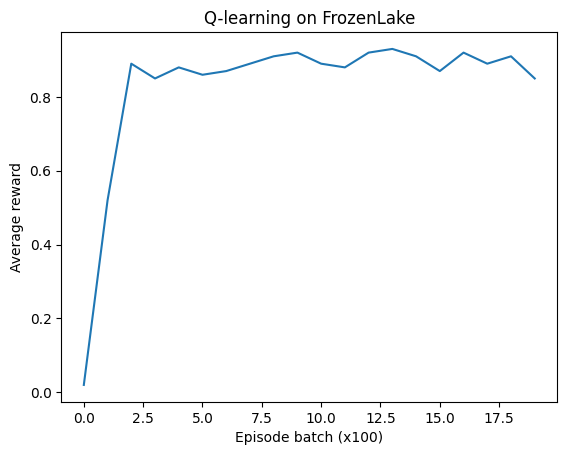

In [8]:
import matplotlib.pyplot as plt

# average reward over rolling windows of 100 episodes
window = 100
avg_rewards = [np.mean(rewards_per_episode[i:i+window])
               for i in range(0, len(rewards_per_episode), window)]

plt.plot(avg_rewards)
plt.xlabel(f"Episode batch (x{window})")
plt.ylabel("Average reward")
plt.title("Q-learning on FrozenLake")
plt.show()

In [9]:
# what does the agent think is the best action in each state?
policy = np.argmax(Q, axis=1)
action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']

for s in range(16):
    print(f"State {s}: {action_names[policy[s]]}")

State 0: DOWN
State 1: LEFT
State 2: LEFT
State 3: LEFT
State 4: DOWN
State 5: LEFT
State 6: DOWN
State 7: LEFT
State 8: RIGHT
State 9: RIGHT
State 10: DOWN
State 11: LEFT
State 12: LEFT
State 13: UP
State 14: RIGHT
State 15: LEFT


In [10]:
state, info = env.reset()
terminated = truncated = False
steps = 0

while not (terminated or truncated) and steps < 100:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, info = env.step(action)
    steps += 1

print("steps taken:", steps)
print("reached goal:", reward == 1)

steps taken: 6
reached goal: True


In [11]:
print("total (state,action) pairs:", N.size)
print("pairs visited at least once:", np.sum(N > 0))
print("pairs never visited:", np.sum(N == 0))

# which specific ones never got touched
never_visited = np.argwhere(N == 0)
print(never_visited)

total (state,action) pairs: 64
pairs visited at least once: 44
pairs never visited: 20
[[ 5  0]
 [ 5  1]
 [ 5  2]
 [ 5  3]
 [ 7  0]
 [ 7  1]
 [ 7  2]
 [ 7  3]
 [11  0]
 [11  1]
 [11  2]
 [11  3]
 [12  0]
 [12  1]
 [12  2]
 [12  3]
 [15  0]
 [15  1]
 [15  2]
 [15  3]]


other comparisions - sarsa

In [12]:
# SARSA needs to know the actual next action before computing the target
# — not just the best possible one.
alpha = 0.8     # learning rate
gamma = 0.95    # discount factor
epsilon = 1  # exploration rate
epsilon_min = 0.1
decay_rate = 0.995
n_episodes = 2000

rewards_per_episode = []
N = np.zeros([env.observation_space.n, env.action_space.n])

for episode in range(n_episodes):
    state, info = env.reset()
    terminated = truncated = False
    total_reward = 0

    # pick the FIRST action before the loop starts
    if np.random.random() < epsilon:
        action = env.action_space.sample()
    else:
        action = np.argmax(Q[state])

    while not (terminated or truncated):
        next_state, reward, terminated, truncated, info = env.step(action)

        # pick the NEXT action using the same policy, from next_state
        if np.random.random() < epsilon:
            next_action = env.action_space.sample()
        else:
            next_action = np.argmax(Q[next_state])

        N[state, action] += 1

        # SARSA target uses Q[next_state, next_action] — the actual next action, not max
        Q[state, action] += alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state = next_state
        action = next_action       # carry forward — this IS the SARSA part
        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon = max(epsilon_min, epsilon * decay_rate)

print("Training done.")
print(Q)

Training done.
[[0.22752306 0.70404136 0.07145068 0.04206669]
 [0.04496998 0.         0.04127755 0.03534528]
 [0.04476559 0.02487433 0.02530154 0.02220007]
 [0.02472916 0.         0.02394052 0.00658133]
 [0.49674006 0.77784164 0.         0.45539063]
 [0.         0.         0.         0.        ]
 [0.         0.00712714 0.         0.02467146]
 [0.         0.         0.         0.        ]
 [0.13120616 0.         0.1709932  0.1308464 ]
 [0.1681398  0.17669179 0.72892154 0.        ]
 [0.72706295 0.94238846 0.         0.03285796]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.35168431 0.94832974 0.69194532]
 [0.85635385 0.94998784 1.         0.86701372]
 [0.         0.         0.         0.        ]]


In [13]:
print("total (state,action) pairs:", N.size)
print("pairs visited at least once:", np.sum(N > 0))
print("pairs never visited:", np.sum(N == 0))

# which specific ones never got touched
never_visited = np.argwhere(N == 0)
print(never_visited)

total (state,action) pairs: 64
pairs visited at least once: 44
pairs never visited: 20
[[ 5  0]
 [ 5  1]
 [ 5  2]
 [ 5  3]
 [ 7  0]
 [ 7  1]
 [ 7  2]
 [ 7  3]
 [11  0]
 [11  1]
 [11  2]
 [11  3]
 [12  0]
 [12  1]
 [12  2]
 [12  3]
 [15  0]
 [15  1]
 [15  2]
 [15  3]]


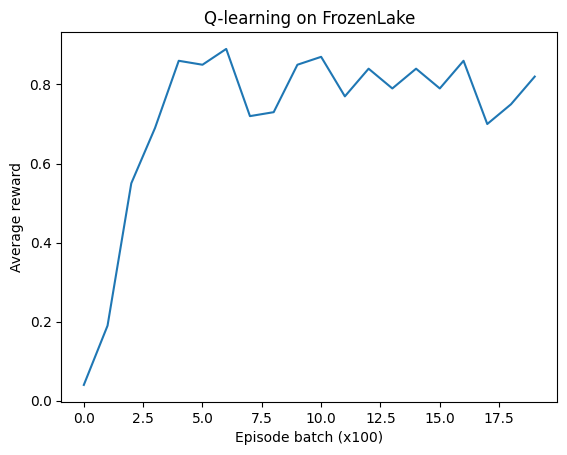

In [14]:
# average reward over rolling windows of 100 episodes
window = 100
avg_rewards = [np.mean(rewards_per_episode[i:i+window])
               for i in range(0, len(rewards_per_episode), window)]

plt.plot(avg_rewards)
plt.xlabel(f"Episode batch (x{window})")
plt.ylabel("Average reward")
plt.title("Q-learning on FrozenLake")
plt.show()

In [15]:
policy = np.argmax(Q, axis=1)
action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']

for s in range(16):
    print(f"State {s}: {action_names[policy[s]]}")

State 0: DOWN
State 1: LEFT
State 2: LEFT
State 3: LEFT
State 4: DOWN
State 5: LEFT
State 6: UP
State 7: LEFT
State 8: RIGHT
State 9: RIGHT
State 10: DOWN
State 11: LEFT
State 12: LEFT
State 13: RIGHT
State 14: RIGHT
State 15: LEFT


In [16]:
state, info = env.reset()
terminated = truncated = False
steps = 0

while not (terminated or truncated) and steps < 100:
    action = np.argmax(Q[state])
    state, reward, terminated, truncated, info = env.step(action)
    steps += 1

print("steps taken:", steps)
print("reached goal:", reward == 1)

steps taken: 6
reached goal: True
